# **Lab 1: Gapminder Data Visualization**

Gapminder is a nonprofit organization that compiles data on a variety of world health and development variables and provides point-and-click tools for interacting with and visualizing the data. Check out Gapminder here. In the Tools section you can play around with the data visualization tools. It’s pretty amazing as it’s really easy to visualize 4+ variables all at once, and to change the variables you want to visualize. Be sure to experiment a little bit before proceeding with this lab.

In the Data section all of the data sets that are available to visualize can be downloaded very easily for free.

**Setup**
If you haven’t already done so, create a folder for our course. From here it should be convenient to navigate to all of our assignments and materials that you organize together.

Create a “Data” subfolder and download the q1data.csv, q2data.csv, and q3data.csv files from Canvas to this subfolder.

Complete this assignment in an .ipynb or a .qmd file that you will render to HTML using quarto. Use a new theme or other visual customizations of your liking to spice up your submission! Just google “quarto themes” to see all the awesome options that are out there!
- Note of Quarto themes I like: [Litera](https://), [Zephyr](https://), [Lux](https://)

Unless otherwise specified, you should echo your code for each of your code chunks so that we can see it in your output file.

**Instructions**
You will be given a few plots and data sets from Gapminder below. In each case:

1. Identify what aesthetics are being used and which variables are being mapped to each aesthetic.
2. Import the data set and recreate the plot as best you can using plotnine. You should recreates:
- The geometry
- The aesthetics
- The scales (meaning the numeric axis choices, the colors that represent different categories, and the shapes that represent information)
- You do not need to recreate any extra “themes” stuff, like the font and the background, but we encourage you to try for practice.

Note: because the data is updated over time, there might be some differences in the details between the plots provided here and the ones you create. You should see the same general trends, but some of the individual points might be a little different. These differences are fine.

3. What other geometries could you use here besides geom_point? Provide an actual plot of another geometry being used here and why it’s good or bad for visualizing this data.
It doesn’t necessarily need to be a “good” geometry, but it does need to work with the variables involved. So you can’t just pick a “random” geometry (for example, you can’t make a box plot of a categorical variable).

- One of the morals for this part is “just because you can do it doesn’t mean you should.” So try to find a geom that works with all the given variables, but keep in mind that the resulting plot might not be very good, in which case you should discuss its disadvantages.

# Task 1
Plot 1 below is based on the q1data.csv dataset.

## What aesthetics are being used?


*   Size
*   Color
*   X & Y Position



## Which variables are being mapped to each aesthetic?
*   Size -> Population size
*   Color -> World region
*   X Position -> Income (GDP per capita, inflation-adjusted)
*   Y Position -> Life expectancy (years)

In [14]:
import pandas as pd
from plotnine import *

In [131]:
df_q1 = pd.read_csv("https://raw.githubusercontent.com/nateposner/5544/refs/heads/main/5544-Lab-1/q1data.csv")
df_q1.head()

,income,life_exp,population,year,country,four_regions,six_regions,eight_regions,world_bank_region
0,1910.0,61.0,29200000.0,2010,Afghanistan,asia,south_asia,asia_west,South Asia
1,11100.0,78.1,2950000.0,2010,Albania,europe,europe_central_asia,europe_east,Europe & Central Asia
2,11100.0,74.7,36000000.0,2010,Algeria,africa,middle_east_north_africa,africa_north,Middle East & North Africa
3,46900.0,81.9,84500.0,2010,Andorra,europe,europe_central_asia,europe_west,Europe & Central Asia
4,7680.0,60.8,23400000.0,2010,Angola,africa,sub_saharan_africa,africa_sub_saharan,Sub-Saharan Africa


In [132]:
breaks = [500, 1000, 2000, 4000, 8000, 16000, 32000, 64000]
labels = ["500", "1000", "2000", "4000", "8000", "16k", "32k", "64k"]

plot_q1 = (ggplot(df_q1,
aes(x = "income", y = "life_exp", size = "population", color = "four_regions"))
+ geom_point()
+ scale_x_log10(breaks = breaks, labels = labels, limits=(500, 110000))
+ scale_size_continuous(range=(1, 20))                    # makes population bubble sizes vary more
+ scale_color_manual(values={
                            "africa": "#20DCE8",
                            "americas": "#70E820",
                            "asia": "#FA434C",
                            "europe": "gold"
                            })
+ theme_bw()                                              # removes the grey background and replaces with a more normal grid
+ theme(figure_size=(10, 5))                              # makes the graph aspect ratio more accurate to the original
)

/usr/local/lib/python3.13/dist-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 4 rows containing missing values.


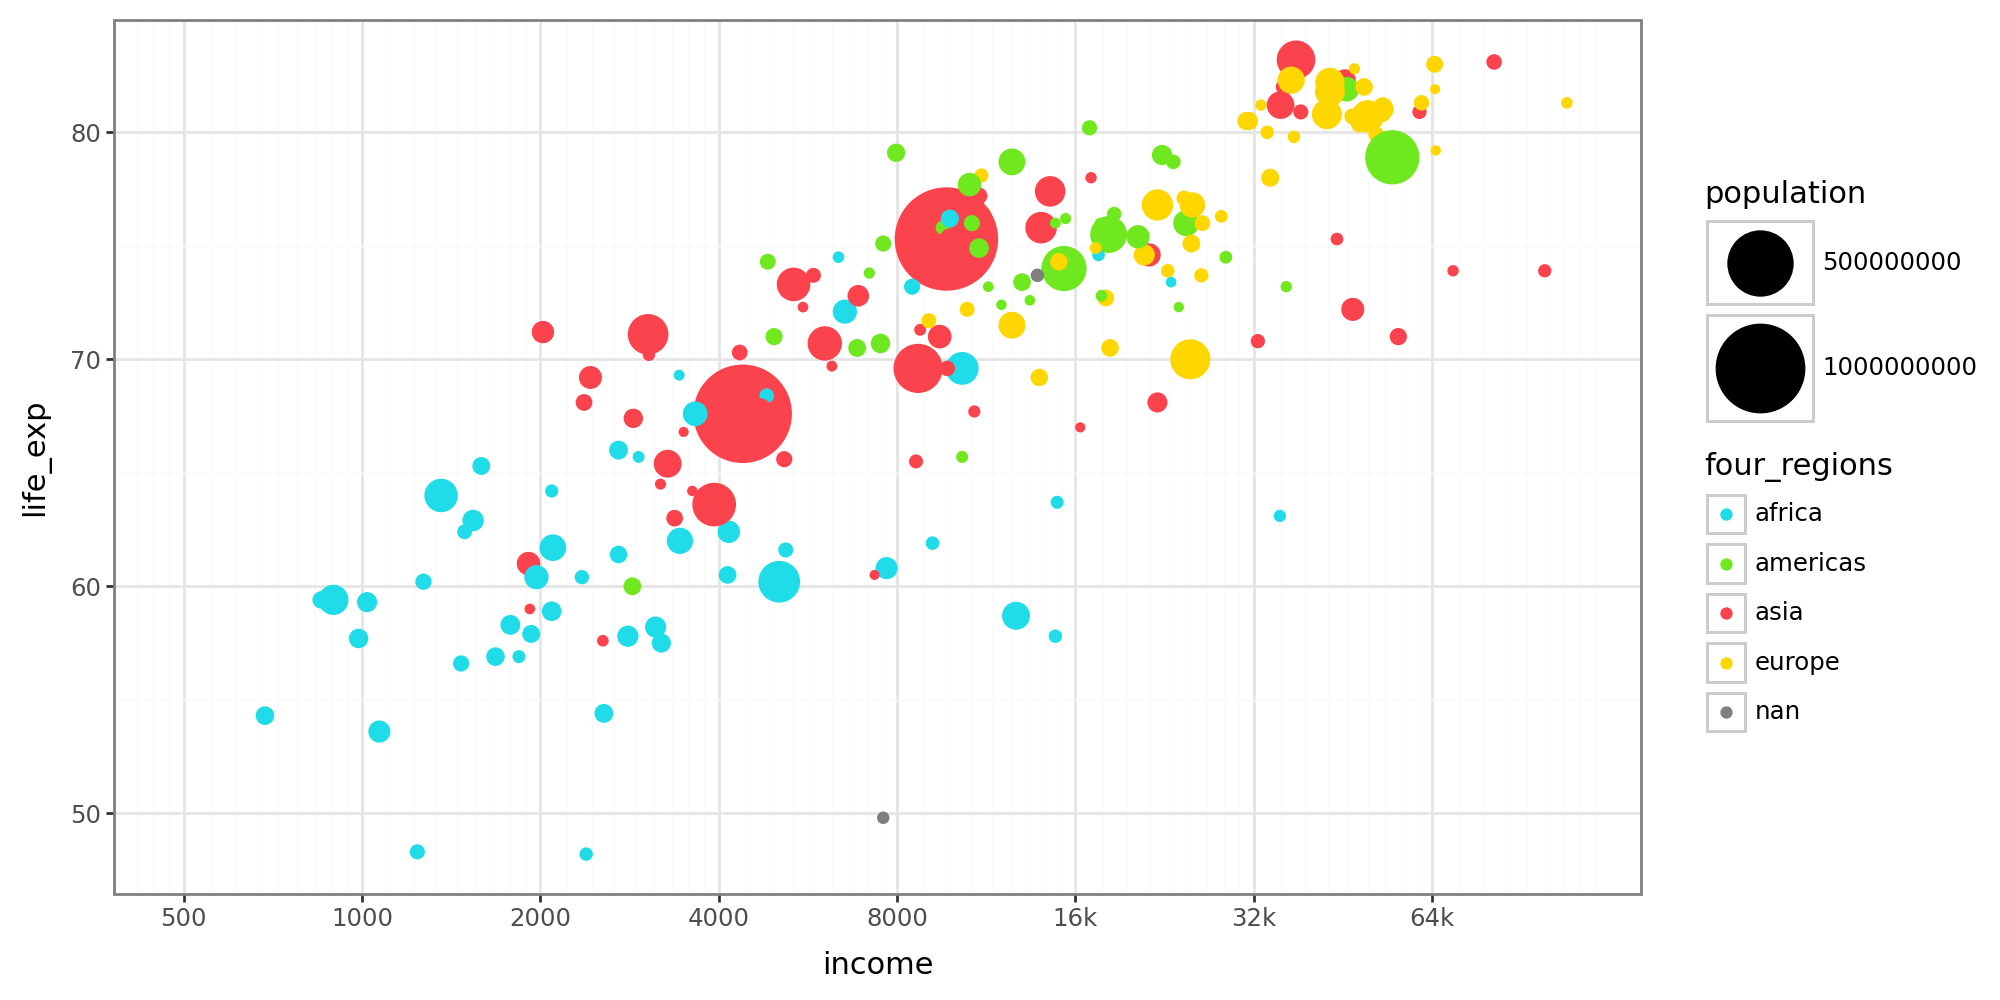

In [133]:
plot_q1

### Original Plot 1 (visual reference)

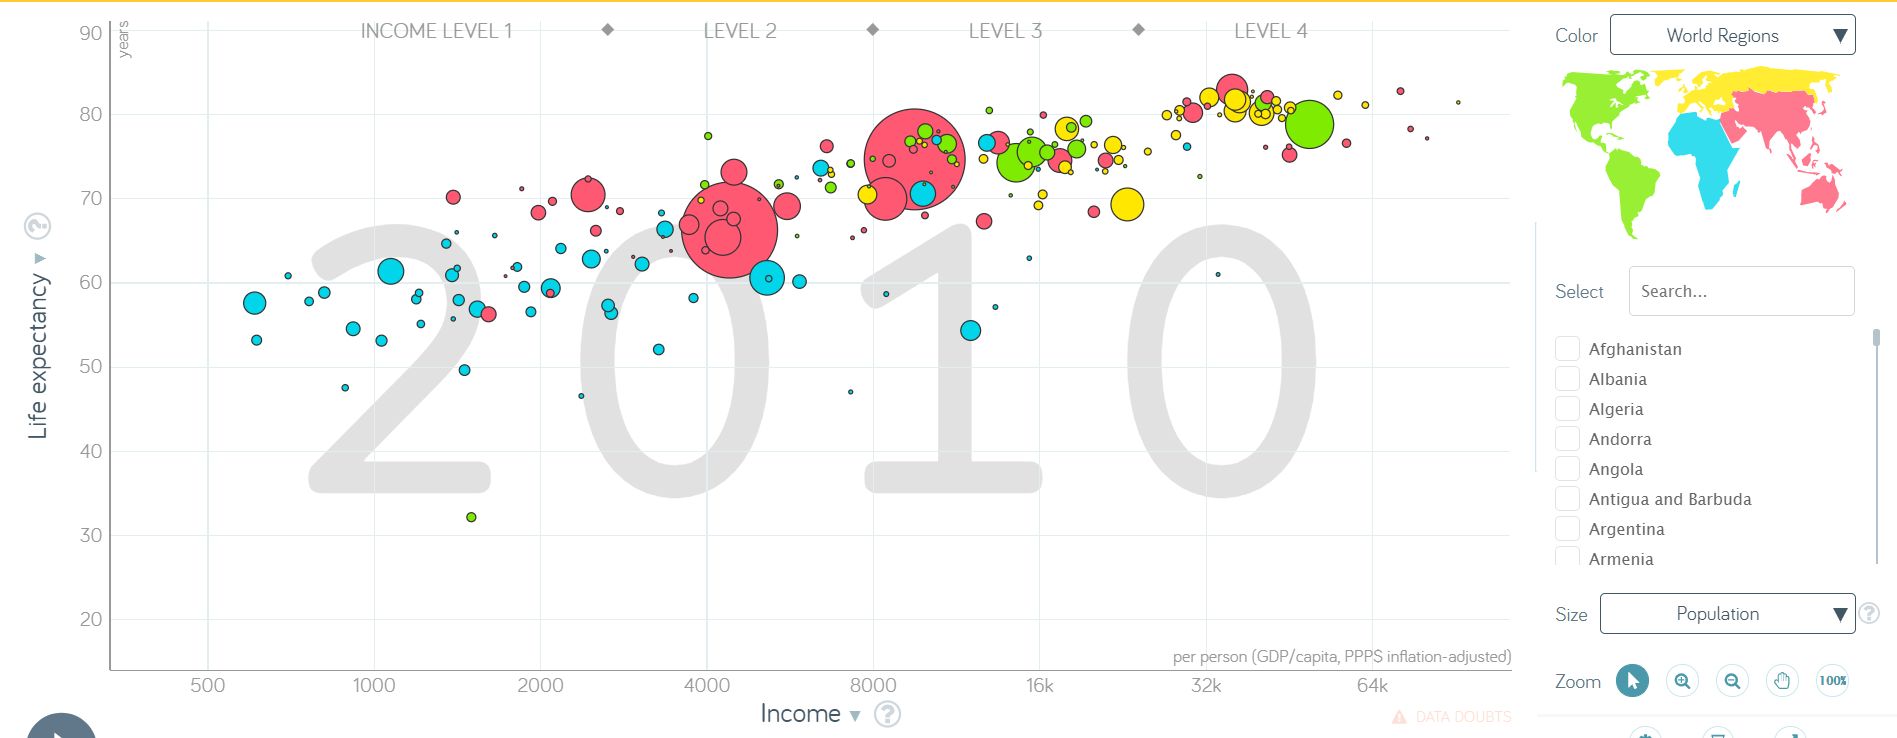

### Alternate geometry for Plot 1: 2d density chart


In [154]:
df_q1_clean = df_q1[df_q1["four_regions"].notna()]

plot_2d_density = (
    ggplot(df_q1_clean, aes(x="income", y="life_exp", color="four_regions"))
    + geom_density_2d()
    + scale_x_log10(breaks=breaks, labels=labels, limits=(500, 110000))
    + scale_color_manual(values={"africa": "#20DCE8", "americas": "#70E820", "asia": "#FA434C", "europe": "gold"})
    + theme_bw()
    + theme(figure_size=(10, 5))
)

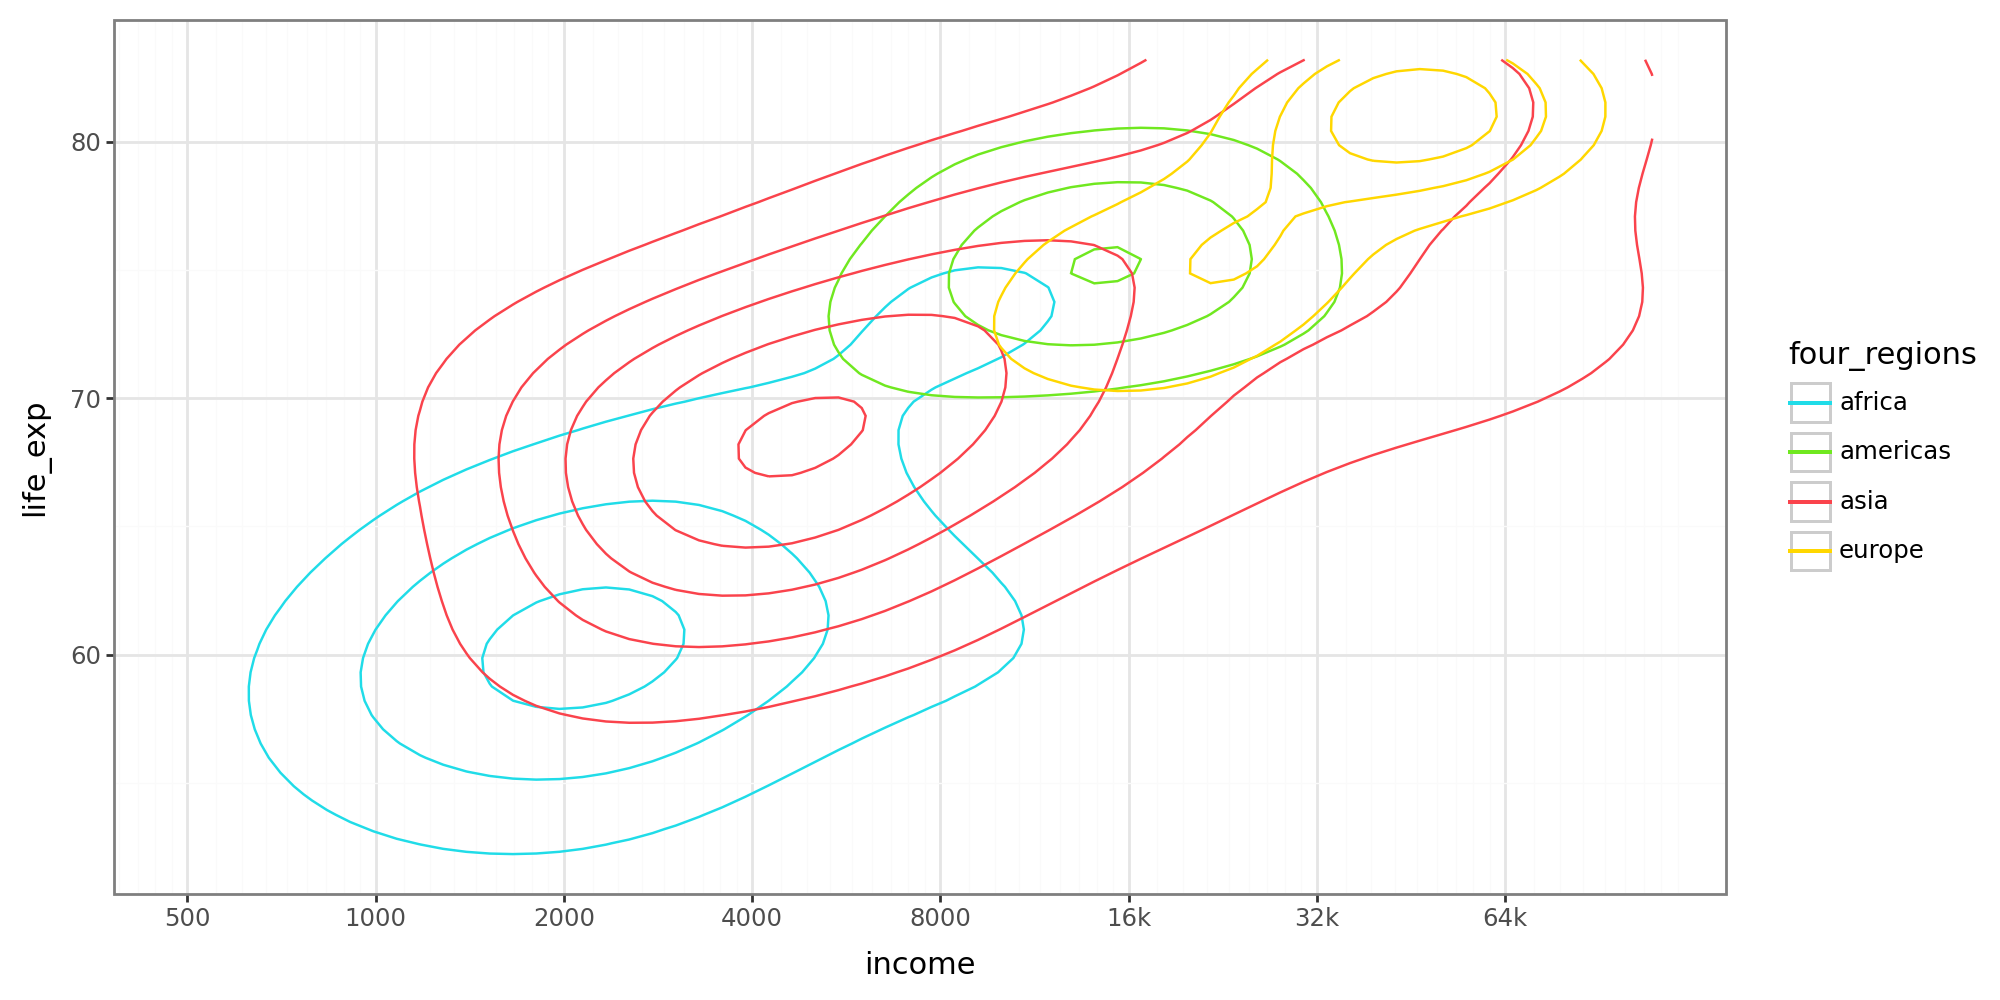

In [155]:
plot_2d_density

### Alternate geometry for Plot 1: Bin 2d
This one is far worse than the one above in my opinion, it was interesting to try out something new though.


/usr/local/lib/python3.13/dist-packages/plotnine/layer.py:364: PlotnineWarning: geom_bin_2d : Removed 1 rows containing missing values.


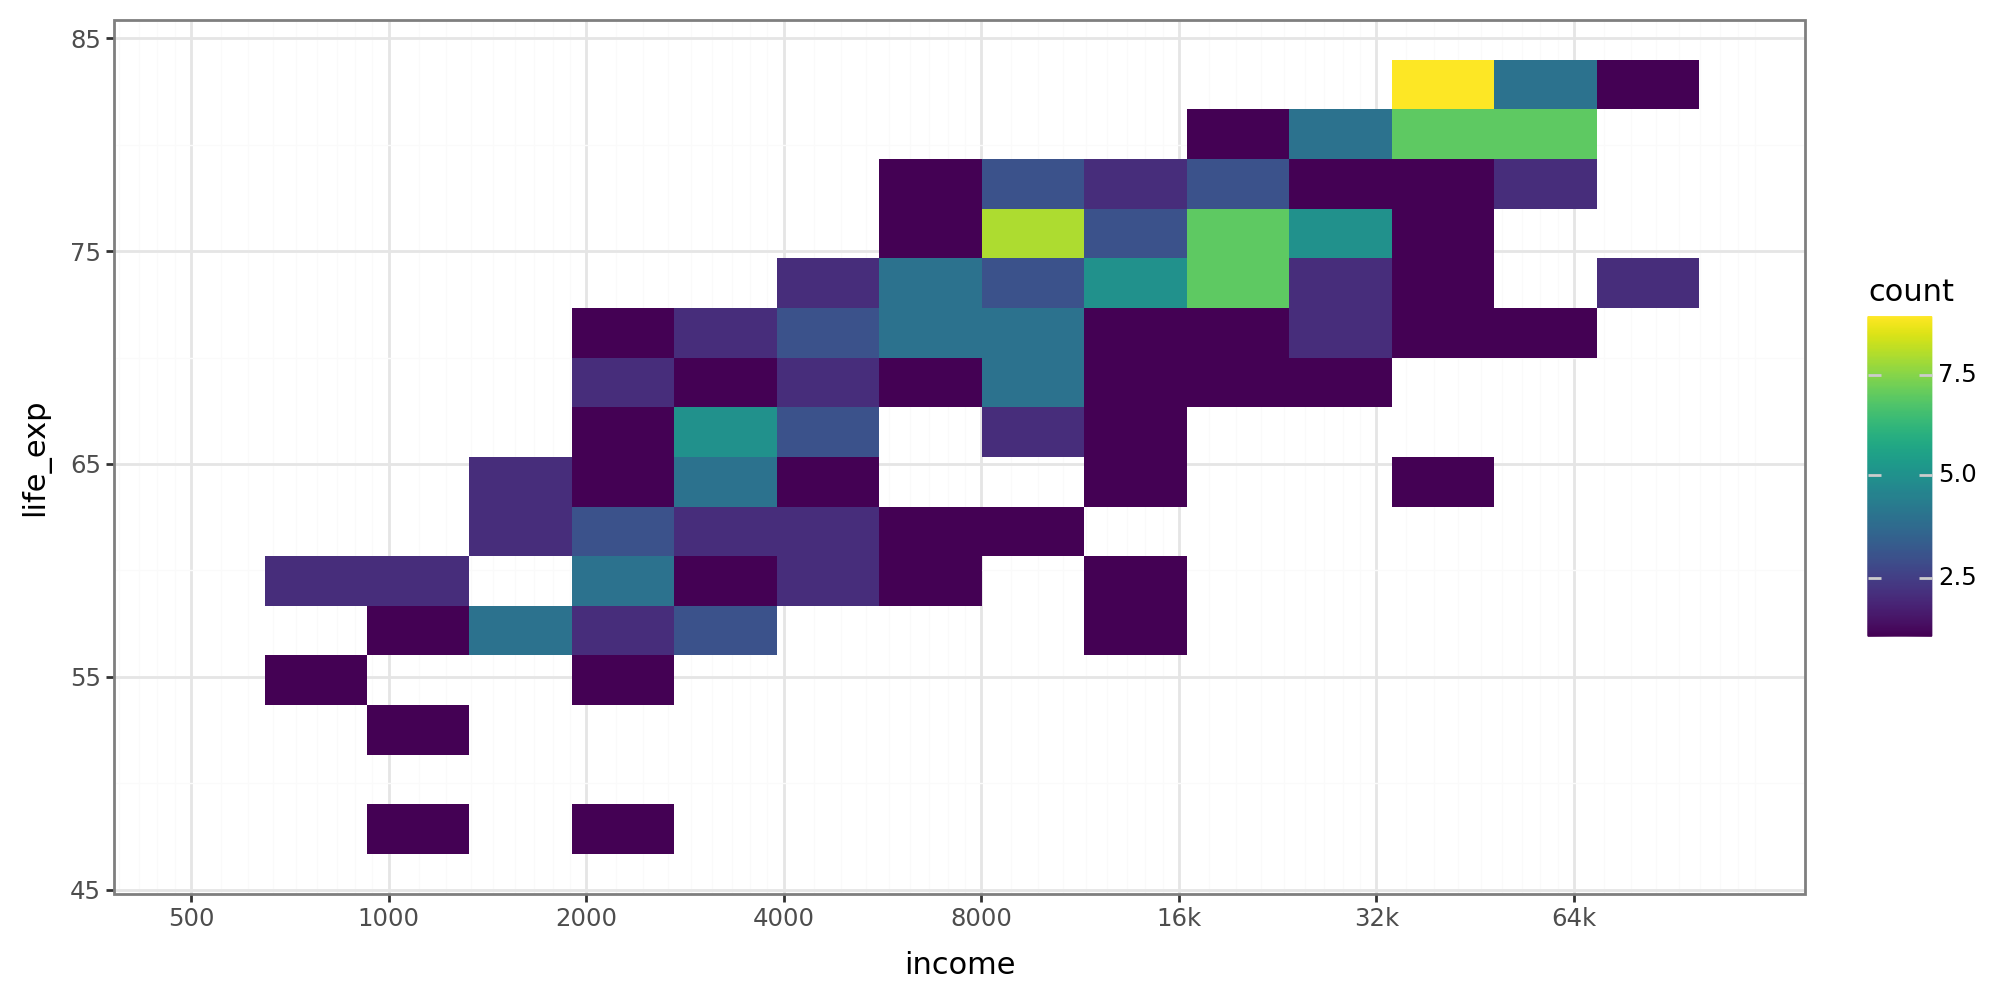

In [156]:
plot_bin2d = (
    ggplot(df_q1_clean, aes(x="income", y="life_exp"))
    + geom_bin2d(bins=15)
    + scale_x_log10(breaks=breaks, labels=labels, limits=(500, 110000))
    + theme_bw()
    + theme(figure_size=(10, 5))
)
plot_bin2d

# Task 2
Plot 2 below is based on the q2data.csv dataset.

## What aesthetics are being used?

*   Size
*   Color
*   X & Y Position

## Which variables are being mapped to each aesthetic?
*   Size -> Energy Use
*   Color -> World Region
*   X Position -> Exports (\% of GDP)
*   Y Position -> Imporgts (\% of GDP)

In [12]:
df_q2 = pd.read_csv("https://raw.githubusercontent.com/nateposner/5544/refs/heads/main/5544-Lab-1/q2data.csv")
df_q2.head()

,imports,exports,energy,year,country,four_regions,six_regions,eight_regions,world_bank_region
0,NaN,NaN,NaN,1997,Afghanistan,asia,south_asia,asia_west,South Asia
1,36.7,11.5,427,1997,Albania,europe,europe_central_asia,europe_east,Europe & Central Asia
2,22.5,22.6,825,1997,Algeria,africa,middle_east_north_africa,africa_north,Middle East & North Africa
3,NaN,NaN,NaN,1997,American Samoa,NaN,NaN,NaN,NaN
4,NaN,NaN,434,1997,Angola,africa,sub_saharan_africa,africa_sub_saharan,Sub-Saharan Africa


In [75]:
# I'm getting issues creating a simple plot, seemingly from the energy data. Trying to find the source of the problem.
df_q2["energy"].describe()

,energy
count,137
unique,133
top,340
freq,2


In [86]:
# Finding where the problem is in the data.... who would even log data like this
filtered_k = df_q2[df_q2["energy"].str.contains("k", na=False)]
filtered_k

,imports,exports,energy,year,country,four_regions,six_regions,eight_regions,world_bank_region
13,63.9,64.6,12.4k,1997,Bahrain,asia,middle_east_north_africa,asia_west,Middle East & North Africa
46,NaN,NaN,18.8k,1997,Curaçao,NaN,NaN,NaN,NaN
151,40.0,51.1,19.3k,1997,Qatar,asia,middle_east_north_africa,asia_west,Middle East & North Africa
194,NaN,NaN,11.2k,1997,United Arab Emirates,asia,middle_east_north_africa,asia_west,Middle East & North Africa


In [87]:
# Converting the data with k into normal numeric values

import numpy as np

has_k = df_q2["energy"].str.contains("k", na=False)

df_q2["energy_numeric"] = np.nan
df_q2.loc[has_k, "energy_numeric"] = df_q2.loc[has_k, "energy"].str.replace("k", "", regex=False).astype(float) * 1000
df_q2.loc[~has_k, "energy_numeric"] = df_q2.loc[~has_k, "energy"].astype(float)

In [103]:
# Checking a few values
df_q2.loc["150":"160"]

,imports,exports,energy,year,country,four_regions,six_regions,eight_regions,world_bank_region,energy_numeric
150,40.3,56.00,NaN,1997,Puerto Rico,NaN,NaN,NaN,NaN,NaN
151,40.0,51.10,19.3k,1997,Qatar,asia,middle_east_north_africa,asia_west,Middle East & North Africa,19300.0
152,30.8,23.00,1820,1997,Romania,europe,europe_central_asia,europe_east,Europe & Central Asia,1820.0
153,24.6,31.20,3980,1997,Russia,europe,europe_central_asia,europe_east,Europe & Central Asia,3980.0
154,23.2,5.59,NaN,1997,Rwanda,africa,sub_saharan_africa,africa_sub_saharan,Sub-Saharan Africa,NaN
155,NaN,NaN,NaN,1997,Samoa,asia,east_asia_pacific,east_asia_pacific,East Asia & Pacific,NaN
156,NaN,NaN,NaN,1997,San Marino,europe,europe_central_asia,europe_west,Europe & Central Asia,NaN
157,NaN,NaN,NaN,1997,Sao Tome and Principe,NaN,NaN,NaN,NaN,NaN
158,26.5,29.60,4650,1997,Saudi Arabia,asia,middle_east_north_africa,asia_west,Middle East & North Africa,4650.0
159,29.5,18.60,229,1997,Senegal,africa,sub_saharan_africa,africa_sub_saharan,Sub-Saharan Africa,229.0


In [117]:
plot_q2 = (ggplot(df_q2,
aes(x = "exports", y = "imports", size = "energy_numeric", color = "four_regions"))
+ geom_point()
+ scale_x_continuous (breaks=range(0, 240, 20))
+ scale_y_continuous(breaks=range(0, 400, 50), limits=(0, 400))
+ scale_size_continuous(range=(1, 15))                    # makes population bubble sizes vary more
+ scale_color_manual(values={
                            "africa": "#20DCE8",
                            "americas": "#70E820",
                            "asia": "#FA434C",
                            "europe": "gold"
                            })
+ theme_bw()                                              # removes the grey background and replaces with a more normal grid
+ theme(figure_size=(10, 5))                              # makes the graph aspect ratio more accurate to the original
)

/usr/local/lib/python3.13/dist-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 78 rows containing missing values.


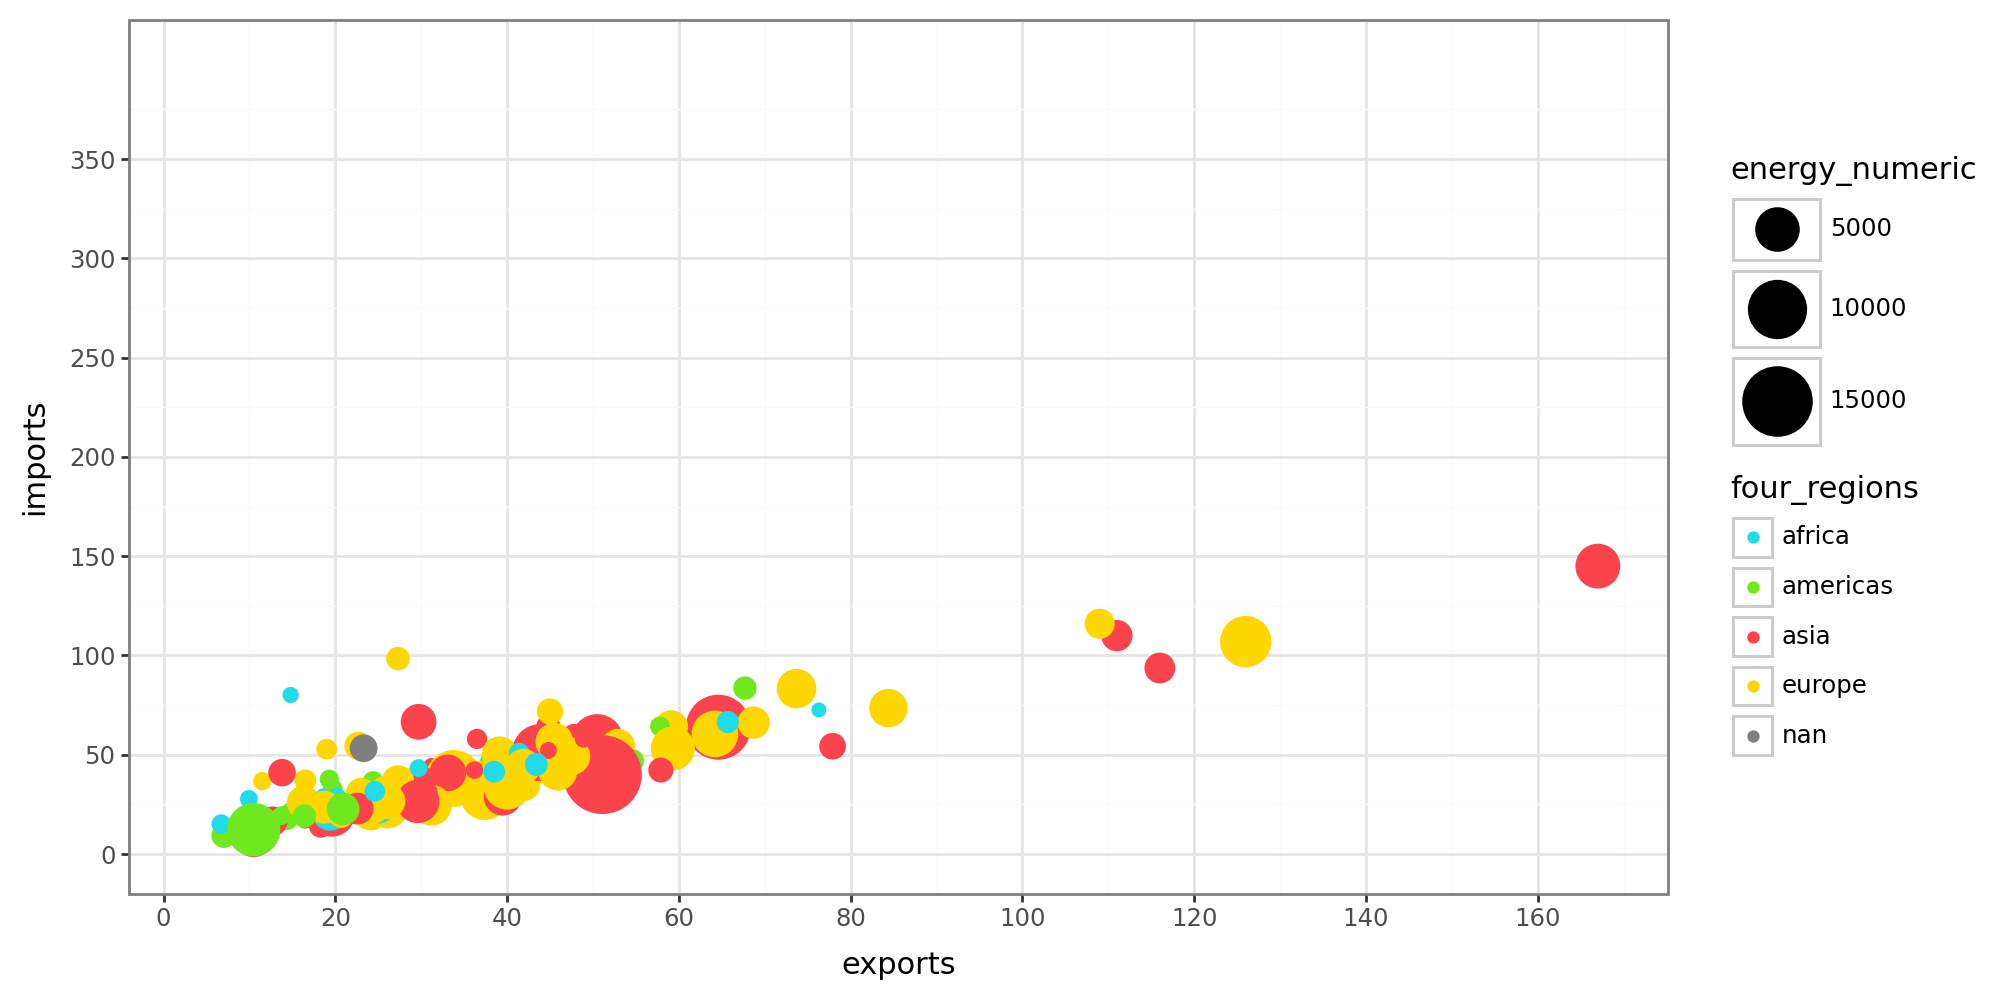

In [118]:
plot_q2

### Original Plot 2 (visual reference)

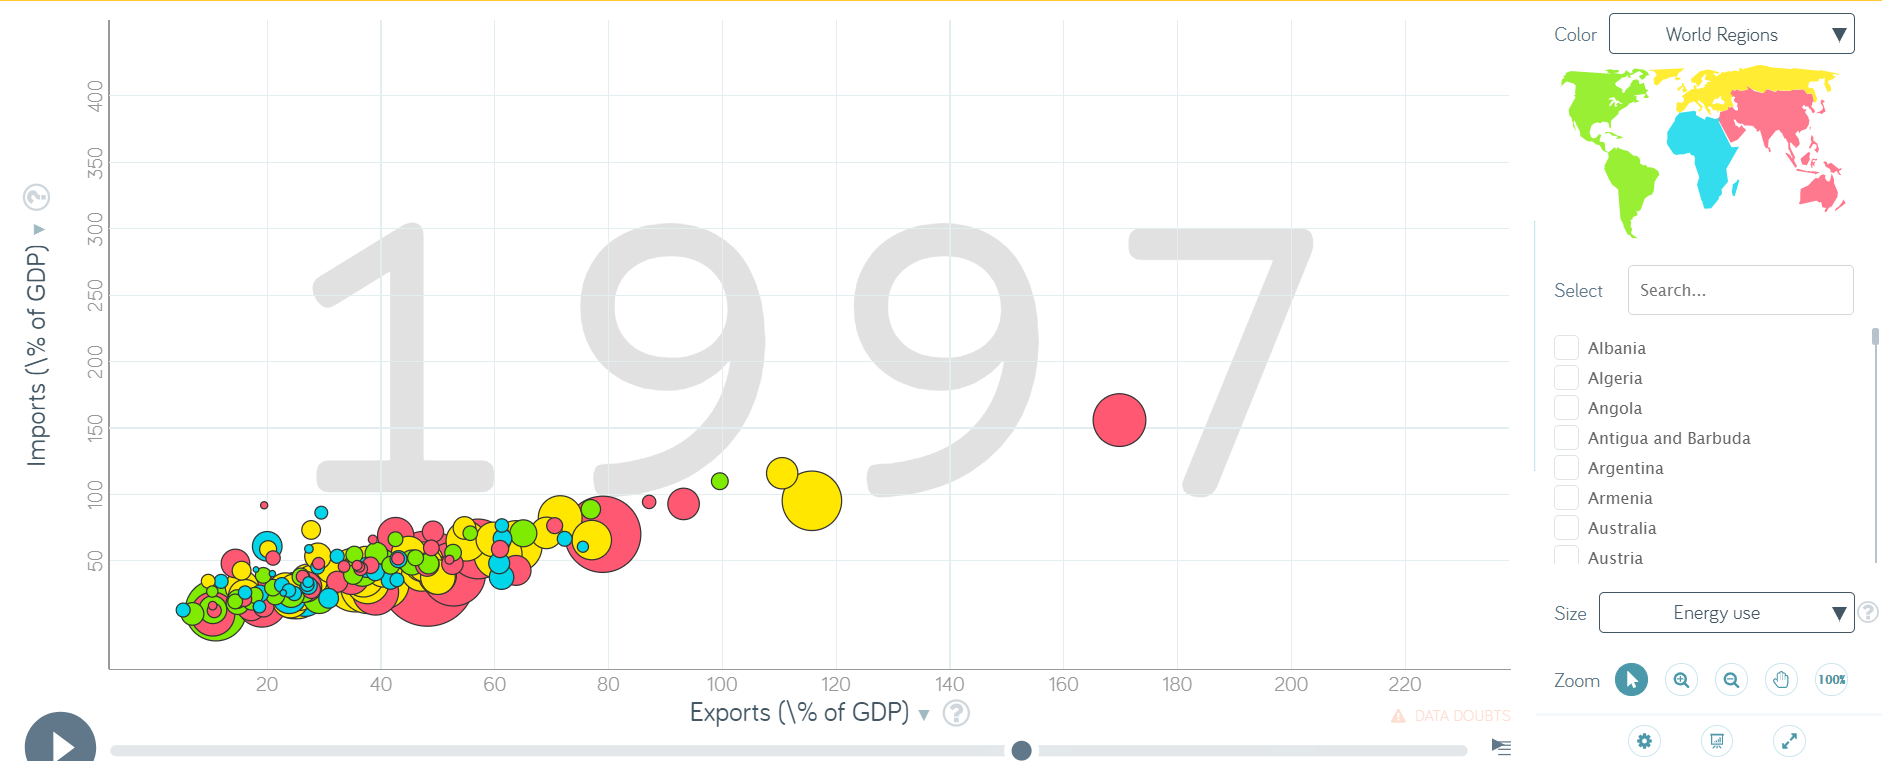

# Task 3
Plot 3 below is based on the q3data.csv dataset.

## What aesthetics are being used?

*   Size
*   Color
*   X & Y Position

## Which variables are being mapped to each aesthetic?
*   Size -> Income
*   Color -> World Region
*   X Position -> Individuals using the internet (as % of the population)
*   Y Position -> GDP per capita

In [13]:
df_q3 = pd.read_csv("https://raw.githubusercontent.com/nateposner/5544/refs/heads/main/5544-Lab-1/q3data.csv")
df_q3.head()

,internet_users,gdp,income,year,country,four_regions,six_regions,eight_regions,world_bank_region
0,0.00456,330.0,1190.0,2001,Afghanistan,asia,south_asia,asia_west,South Asia
1,0.39000,2570.0,6780.0,2001,Albania,europe,europe_central_asia,europe_east,Europe & Central Asia
2,1.59000,3770.0,9230.0,2001,Algeria,africa,middle_east_north_africa,africa_north,Middle East & North Africa
3,NaN,10500.0,NaN,2001,American Samoa,NaN,NaN,NaN,NaN
4,11.30000,42600.0,35600.0,2001,Andorra,europe,europe_central_asia,europe_west,Europe & Central Asia


In [127]:
plot_q3 = (ggplot(df_q3,
aes(x = "internet_users", y = "gdp", size = "income", color = "four_regions"))
+ geom_point()
+ scale_x_continuous (breaks=range(0, 100, 10), limits=(0,100))
+ scale_y_log10()
+ scale_size_continuous(range=(1, 15))                    # makes population bubble sizes vary more
+ scale_color_manual(values={
                            "africa": "#20DCE8",
                            "americas": "#70E820",
                            "asia": "#FA434C",
                            "europe": "gold"
                            })
+ theme_bw()                                              # removes the grey background and replaces with a more normal grid
+ theme(figure_size=(10, 5))                              # makes the graph aspect ratio more accurate to the original
)

/usr/local/lib/python3.13/dist-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 32 rows containing missing values.


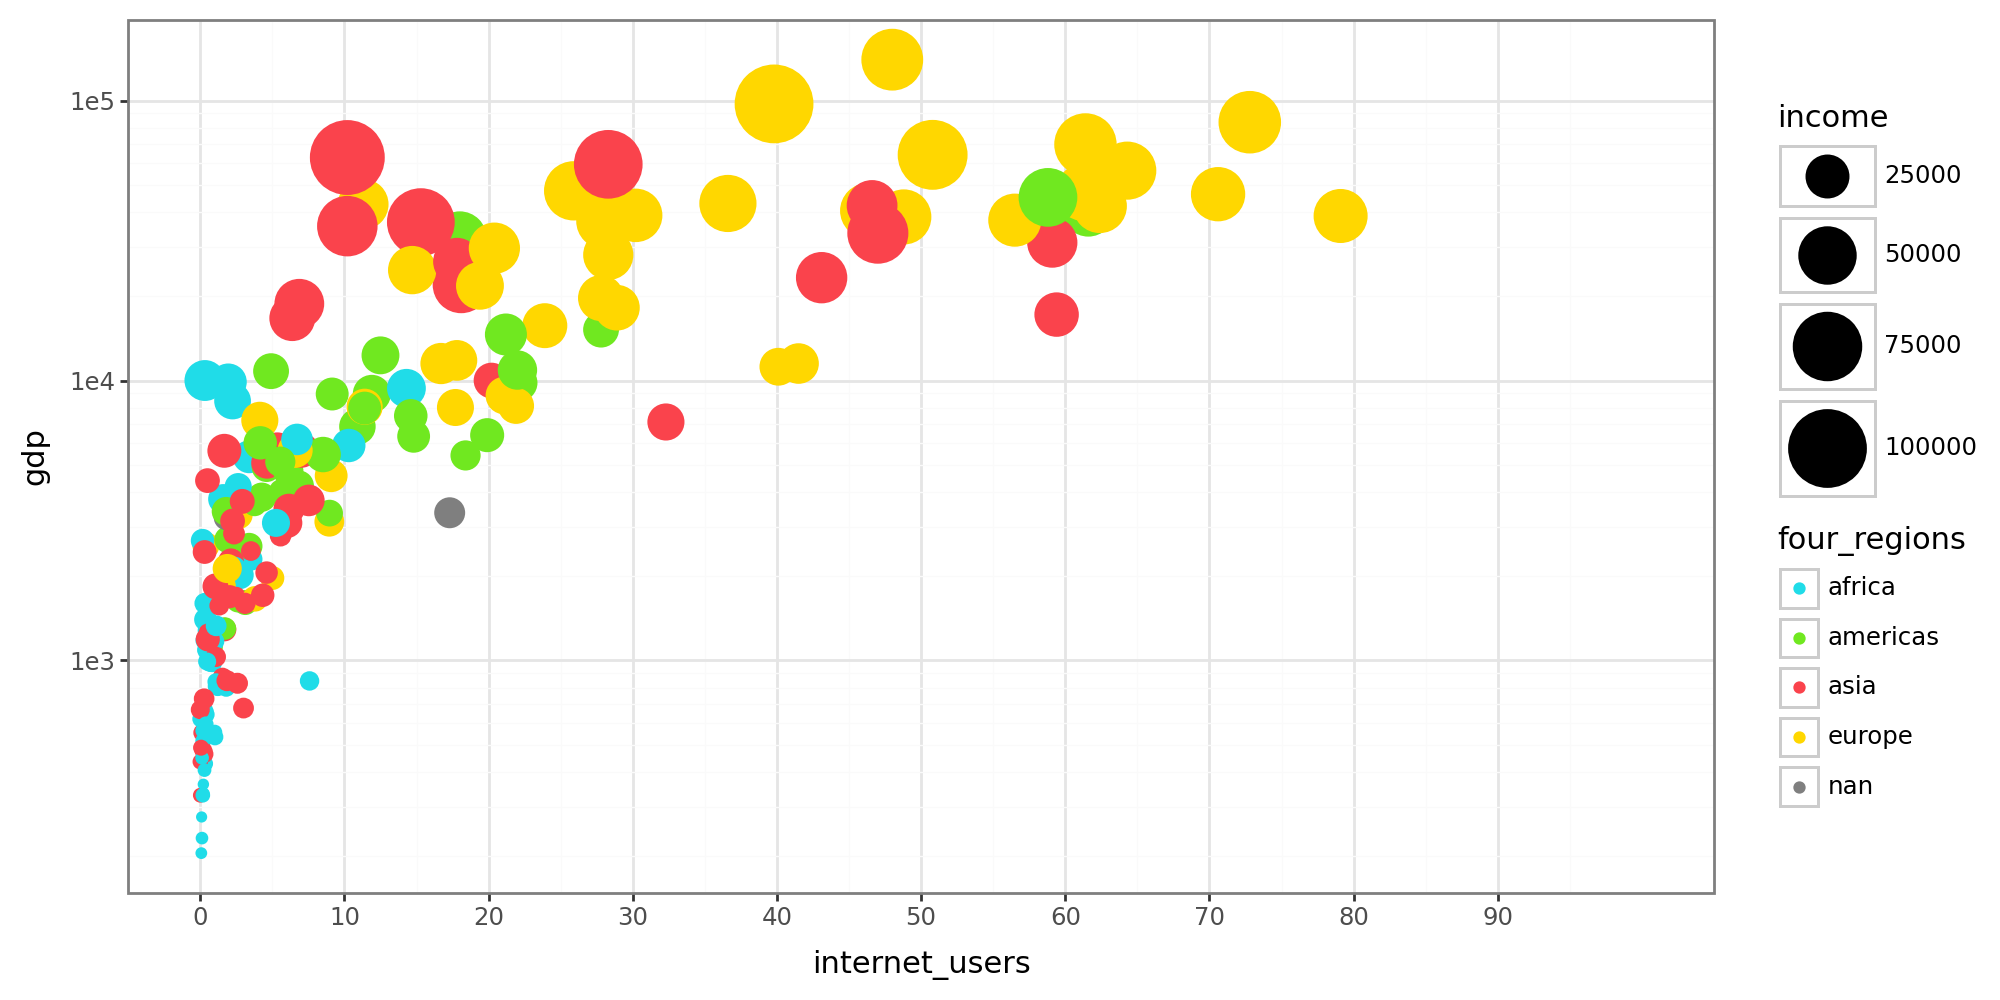

In [124]:
plot_q3

### Original Plot 3 (visual reference)

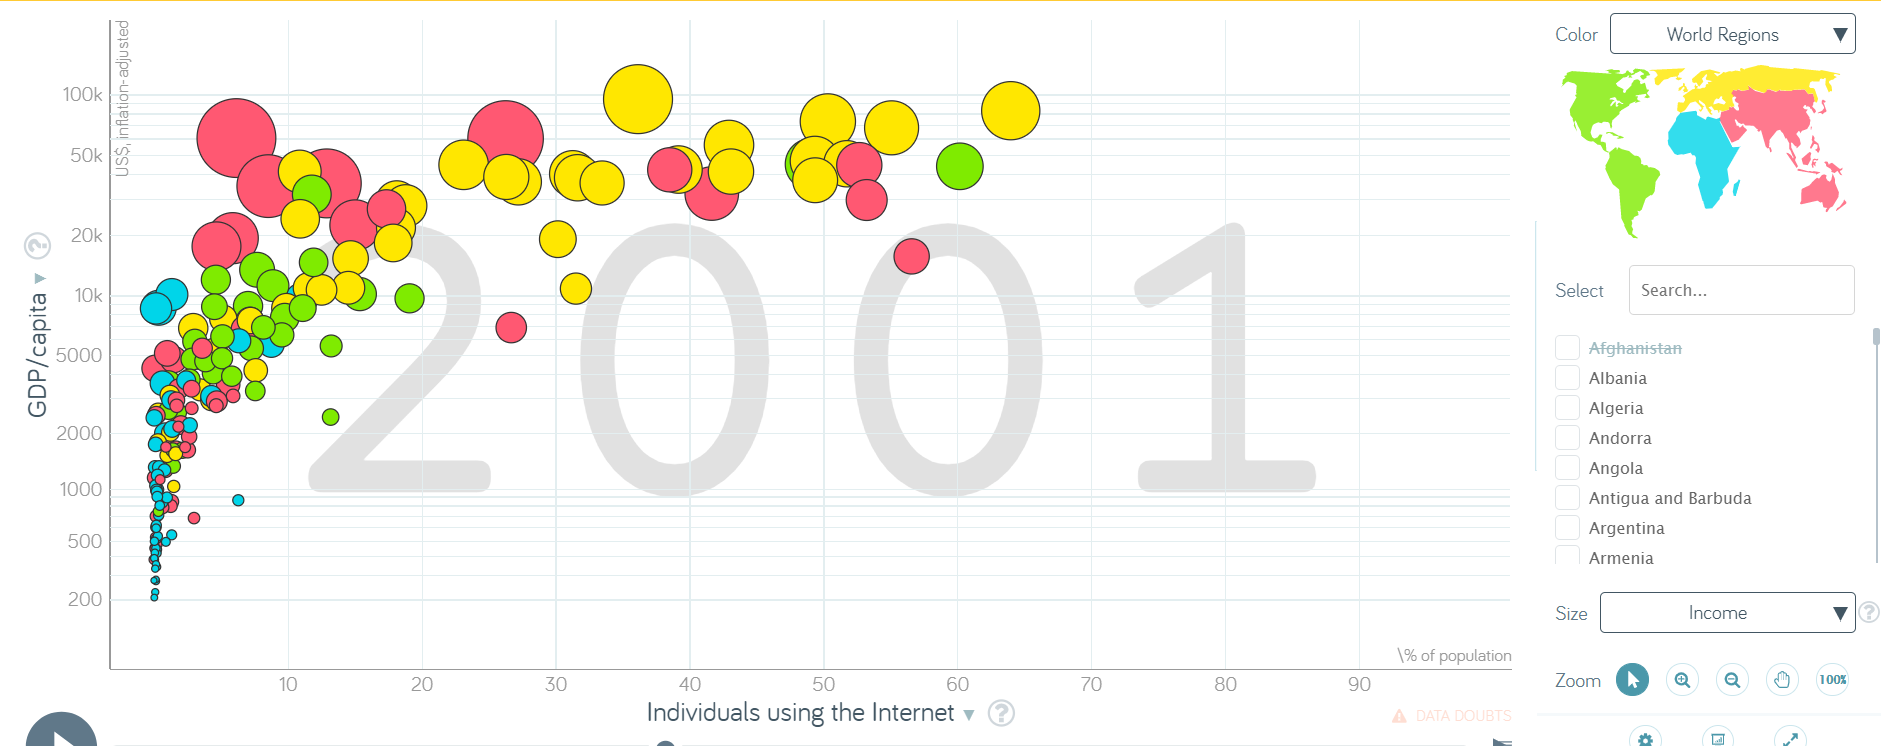